<center>

## Regla compuesta de Simpson

</center>

### Introducción
La integración numérica permite aproximar el valor de una integral definida a partir de evaluaciones de la función en determinados puntos. Entre los métodos se encuentran las formulas de Newton-Cotes, construidas mediante polinomios de interpolación con nodos igualmente espaciados. Sin embargo, al trabajar sobre intervalos largos, estas fórmulas pueden requerir polinomios de grado elevado, cuyos coeficientes son difíciles de obtener y cuyo comportamiento puede presentar oscilaciones. Por esta razon, se utiliza la integración por tramos, que consiste en dividir el intervalo y aplicar fórmulas de bajo grado en segmentos más pequeños.

Dentro de este enfoque se encuentra la regla compuesta de Simpson. Su procedimiento consiste en dividir el intervalo de integración en un número par de subintervalos de igual longitud, aplicar la regla de Simpson sobre cada par consecutivo y sumar las aproximaciones obtenidas. De esta manera, es posible aproximar integrales de la forma

$$
I=\int_a^b f(x)\,dx.
$$

Este metodo resulta útil cuando el calculo analítico es laborioso o cuando se busca una aproximación con una precisión determinada. La subdivisión permite ajustar la separación entre los puntos de evaluación y reducir la cota del error.



La regla de Simpson utiliza tres valores de la función: los correspondientes a los dos extremos del intervalo y a su punto medio. Si $f\in C^4[a,b]$, es decir, si tiene derivadas continuas hasta el cuarto orden, la regla puede escribirse con su termino de error como

$$
\int_a^b f(x)\,dx=\frac{h}{3}\left[f(x_0)+4f(x_1)+f(x_2)\right]-\frac{h^5}{90}f^{(4)}(\xi),
$$

donde $x_0=a$, $x_1=(a+b)/2$, $x_2=b$, $h=(b-a)/2$ y $\xi\in(a,b)$. La aproximacion de la integral se obtiene utilizando la suma ponderada de los tres valores de la función, el último término expresa el error de esa aproximación.

Para mejorar la precisión mediante la subdivisión del intervalo, se introduce la regla compuesta de Simpson. Se selecciona un entero positivo par $n$ y se divide $[a,b]$ en $n$ subintervalos de igual longitud. La separación entre los nodos y sus posiciones se definen mediante

$$
h=\frac{b-a}{n}, \qquad x_j=a+jh, \qquad j=0,1,\ldots,n.
$$

En cada par consecutivo de subintervalos se aplica la regla de Simpson y despues se suman los resultados. La condición de que $n$ sea par permite agrupar todos los subintervalos en pares, cada uno con un extremo izquierdo, un punto intermedio y un extremo derecho, aparte, bajo la condicion $f\in C^4[a,b]$, existe un punto $\mu\in(a,b)$ para el cual tiene un error. Al reunir la aproximacion y el error se obtiene:

$$
\int_a^b f(x)\,dx = \frac{h}{3} \left[ f(a) +2\sum_{j=1}^{n/2-1}f(x_{2j}) +4\sum_{j=1}^{n/2}f(x_{2j-1}) +f(b) \right]-\frac{b-a}{180}h^4f^{(4)}(\mu).
$$

Por tanto, el error de la regla compuesta es de orden $O(h^4)$. A diferencia de una sola aplicación de Simpson sobre todo el intervalo, en la regla compuesta es posible modificar $h$ aumentando el numero de subintervalos. Esto permite reducir la cota del error y ajustar la precisión de la aproximación.



### Regla compuesta de Simpson en Python

In [9]:
def simpson_compuesta(f, a, b, n):# Variables de entrada
    if not isinstance(n, int) or n <= 0 or n % 2 != 0:  # Verifica que n sea entero, positivo y par
        raise ValueError("n debe ser un entero positivo y par.")    # Detiene el calculo si n no es valido

    h = (b - a) / n # Calcula el tamaño de cada subintervalo
    XI0 = f(a) + f(b)  # Suma las evaluaciones en los extremos
    XI1 = 0#Inicializa la suma correspondiente a los indices impares
    XI2 = 0 # Inicializa la suma correspondiente a los indices pares

    for i in range(1, n):  # Recorre los indices desde 1 hasta n - 1
        X = a + i * h #  Calcula el punto donde se evaluara la función
        if i % 2 == 0:  # Comprueba si el indice es par
            XI2 = XI2 + f(X)#    Acumula la evaluacion en la suma de indices pares
        else:# Se ejecuta cuando el indice es impar
            XI1 = XI1 + f(X)  # Acumula la evaluacion en la suma de índices impares

    XI = h * (XI0 + 2 * XI2 + 4 * XI1) / 3  #  Aplica la regla compuesta de Simpson
    return XI # Devuelve la aproximacion de la integral

### Ejemplo

Calcular la aproximacion de la integral:

$$I=\int_{0}^{2} e^{2x} \sin(3x) \, dx$$

con una precisión dentro de $10^{-4}$ y usando $n = 54$ subintervalos.

### Aplicando el codigo

In [11]:
import math  #Libreria que permite usar funciones matematicas

def f(x):#Nuestra funcion a definir
    return math.exp(2 * x) * math.sin(3 * x)

a = 0.0 # Establece el límite inferior
b = 2.0  #Establece el límite superior
n = 54 # Usa los 54 subintervalos indicados

resultado = simpson_compuesta(f, a, b, n)  # Calcula la aproximación con el codigo que hicimos anteriormente
print(f"Aproximacion de la integral: {resultado:.10f}")  #Resultado con 10 decimales

Aproximacion de la integral: -14.2139649001


### Grafica de la integral

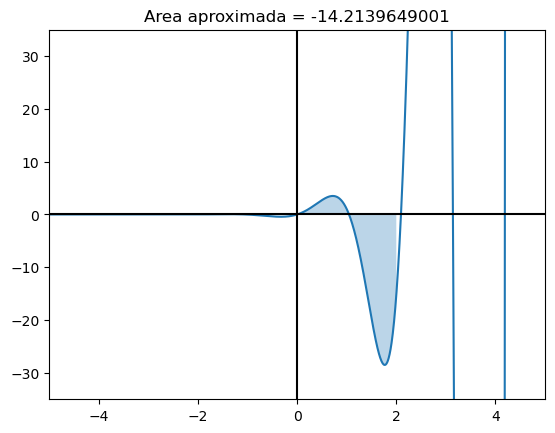

In [34]:
import numpy as np
import matplotlib.pyplot as plt 

x = np.linspace(-5, 5, 2001) #Crea puntos para graficar desde -5 hasta 5
y = np.exp(2 * x) * np.sin(3 * x)#Evalua la función en esos puntos
x_area = np.linspace(0, 2, 1001) #Crea puntos del intervalo que se sombreara
y_area = np.exp(2 * x_area) * np.sin(3 * x_area)  #Evalua la función entre 0 y 2
plt.plot(x, y)  # Dibuja la función
plt.fill_between(x_area, y_area, 0, alpha=0.3)  #Sombrea unicamente el intervalo [0, 2]
plt.axhline(0, color="black")  #Dibuja el eje horizontal
plt.axvline(0, color="black")  # Dibuja el eje vertical
plt.xlim(-5, 5)  # Muestra el eje x 
plt.ylim(-35, 35)   #Muestra el eje 
plt.title(f"Area aproximada = {resultado:.10f}")  # Muestra el área.
plt.show()  #Muestra la grAfica


### Conclusion

Al aplicar la regla de simpson compuesta permitio obtener una aproximación de la integral mediante un procedimiento sencillo. La precision depende del número de subintervalos elegido y del comportamiento de la función. Al aumentar las subdivisiones, disminuye la separación entre los puntos y se reduce la cota del error establecida por la fórmula. Por ello, ajustar el numero de subintervalos permite mejorar el control del error y obtener una aproximación con la precisión buscada.

En este caso en nuestro ejemplo, la aproximacion dada con el codigo que se hizo fue:
$$I=\int_{0}^{2} e^{2x} \sin(3x) \, dx = -14.2139649001 $$